# Creating True Ortho and Digital Surface Model Product from Satellite Imagery

## Introduction

This tutorial demonstrates how to automate photogrammetric correction of satellite imagery and generate reality mapping products using the ArcGIS API for Python. You'll learn to create Digital Surface Models (DSM), Digital Terrain Models (DTM), true ortho imagery, and DSM meshes.
In this workflow, you will process GeoEye satellite imagery through the complete reality mapping pipeline, including:

- Creating a project and mission
- Performing block adjustment
- Generating true ortho and DSM products

This workflow supports satellite images from any sensor platform that uses either rational polynomial coefficients (RPC) or rigorous sensor models, typically embedded in the image file or provided as separate metadata.

The [data for this tutorial](https://esri-rasterdev.maps.arcgis.com/home/item.html?id=83d7bef430544ce8af8bf93ad22653fa) was collected and provided by Maxar Technologies.

## Getting Started

Reality mapping capability through ArcGIS API for Python requires ArcGIS Enterprise federated with a Reality Server license. See the [configuration instruction](https://doctopia.esri.com/builds/reality-server/main/en/deploy/configure-arcgis-reality.html) for setup details.

Once your environment is configured, import the required modules:

- `GIS`module: Manages GIS content, users, and groups

-  [`Realitymapping` module](https://developers.arcgis.com/python/latest/api-reference/arcgis.raster.realitymapping.html) : Automates reality mapping tasks in the server environment.

In [ ]:
import arcgis
from arcgis.gis import GIS
from arcgis.raster import realitymapping

Establish a connection to your ArcGIS Enterprise portal and verify that reality mapping is supported in your environment.

In [ ]:
# connect to GIS
gis = GIS(
    url= "https://yourportal.domain.com/portal",
    username= "your username",
    password= "your password"
)

# confirm that reality mapping is supported
realitymapping.is_supported(gis)


## Step 1: Create a Project

The first step is to create a reality mapping project using the [Project](https://developers.arcgis.com/python/latest/api-reference/arcgis.raster.realitymapping.html#arcgis.raster.realitymapping.Project) class of the reality mapping module.

In [ ]:
project = realitymapping.Project("SatelliteProject", sensor_type= "Satellite")
project

A project is a top-level workspace for managing reality mapping activities. Project creation involves creating a new portal folder and a reality mapping project item inside that folder. The project item contains the basic information (e.g. project name, group name, workspace name, etc.) that defines a reality mapping project. All related image services and products generated in subsequent steps will be stored in the project folder.

In [5]:
# check the project item id
project.item.itemid

'161a3ab8240b414c9313bcf7e9e241e5'

## Step 2: Create a Mission

The next step is to create a mission which is a container for managing all related imagery and the resulting processed data products of a single data capture session. Mission creation involves creating an image collection for the source rasters. So we need to first define the type, properties and path of the source rasters using the [ImageSource](https://developers.arcgis.com/python/latest/api-reference/arcgis.raster.toc.html#imagesource) class. 

Satellite processing is controlled by the raster type and processing template. For this example, we are processing GeoEye-1 and we want to generate Pansharpen product so we define the ImageSource object accordingly. [Check this page for supported satellite sensor raster types](https://pro.arcgis.com/en/pro-app/latest/help/data/imagery/satellite-sensor-raster-types.htm).

In [ ]:
# Create an image source of GeoEye-1 type
sat_src = realitymapping.ImageSource("GeoEye-1")
# Define processing template and dem
sat_src.raster_type.processing_template = "Pansharpen"
sat_src.raster_type.dem = r"C:\SampleData\RM_Satellite_Tutorial\DEM.tif"
# Define the source rasters' path
sat_src.input_data = r"C:\SampleData\RM_Satellite_Tutorial\GeoEye_NAD83_UTM10N"

Other parameters specific to the GeoEye-1 raster type we just created can be defined, similar to the processing_template and dem. To see the possible attributes, use the attributes property of the [raster_type](https://developers.arcgis.com/python/latest/api-reference/arcgis.raster.toc.html#rastertype) instance.

In [7]:
sat_src.raster_type.attributes

{'name': 'GeoEye-1',
 'product_type': None,
 'pansharpen_type': None,
 'pansharpen_weights': None,
 'filter': None,
 'processing_template': 'Pansharpen',
 'dem': 'C:\\SampleData\\RM_Satellite_Tutorial\\DEM.tif',
 'averagezdem': None,
 'constant_z': None,
 'zfactor': None,
 'zoffset': None,
 'correct_geoid': None,
 'estimate_flight_height': None,
 'is_altitude_flight_height': None,
 'minimum_flight_height': None,
 'stretch_type': None,
 'scale_factor': None,
 'valid_range': None}

Now we can create mission using the image source object.

In [ ]:
mission = project.create_mission(image_sources = sat_src, 
                                     out_sr={"wkid": 32610, "vcsWkid": 115700})
mission

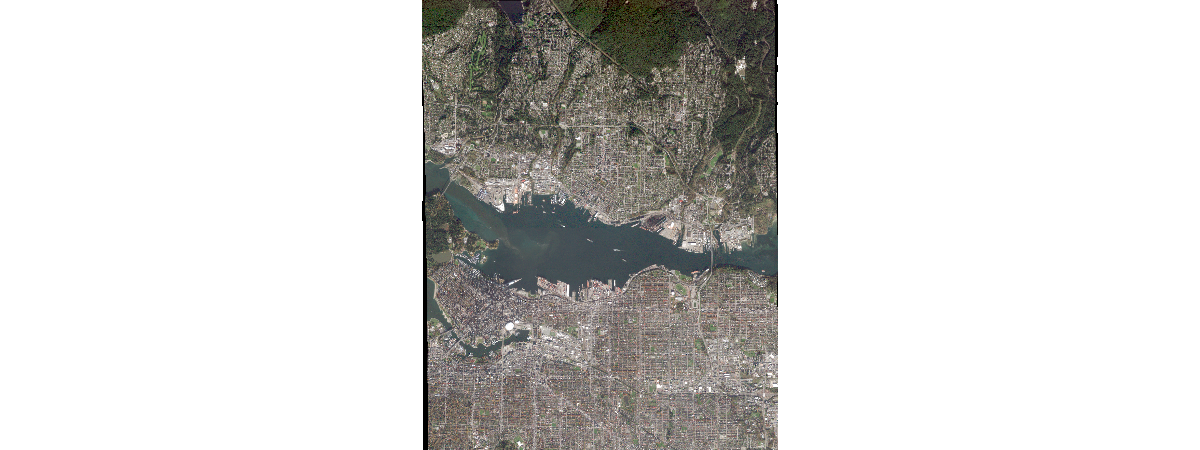

In [11]:
# show unadjusted image collection

mission.image_collection.layers[0]

### Optional: Create another mission for rasters on datastore

You have just created a image collection of panchromatic template using rasters on local folder. Missions can also be created for rasters stored in registered datastores (fileshare, rasterstore or cloudstore).  

The [`list_datastore_content()`](https://developers.arcgis.com/python/latest/api-reference/arcgis.raster.analytics.html#list-datastore-content) function becomes very handy for listing the contents of registered datastores. The parameter argument can be a string of the datastore path or the datastore object. If using a string, the format is `/datastore_type/datastore_name/...` 

To list contents on a cloudstore registered as Azure1: `arcgis.raster.analytics.list_datastore_content(f"/cloudStores/Azure1")`

To list contents on a fileshare registered as fS1: `arcgis.raster.analytics.list_datastore_content(f"/fileShares/fS1")`

In [ ]:
# list the content of the data folder in the cloudstore 
arcgis.raster.analytics.list_datastore_content(f"/fileShares/FS_Desk/RM_Satellite_Tutorial")

Let's create a second mission using multispectral imagery from a FileShate. Since the datastore is registered with the server, we'll set `byref=True` to reference the source rasters directly without copying them to the raster store.

In [ ]:
# Create an image source of GeoEye-1 type
sat_src2 = realitymapping.ImageSource("GeoEye-1")
# Define the source rasters' path
sat_src2.input_data = f"/fileShares/FS_Desk/RM_Satellite_Tutorial"
# Define processing template and dem
sat_src2.raster_type.processing_template = "Multispectral"
sat_src2.raster_type.dem = f"/fileShares/FS_Desk/RM_Satellite_Tutorial/DEM.tif"

# Create mission
mission2 = project.create_mission(image_sources = sat_src2, 
                                     out_sr={"wkid": 32610, "vcsWkid": 115700})
mission2

You've now created two satellite image collections and missions:

- Pansharpen mission from local imagery
- Multispectral mission from fileshare imagery

Multiple missions of different types (UAV, Digital Aerial, Satellite) can be created within a single project.

## Step 3: Perform Adjustment

At this point, your imagery is organized but not yet geometrically adjusted. The next step is to perform block adjustment. 

`Block adjustment` involves using tie points to calculate the exterior orientation for each each image such that they are consistent with neighboring images (Relative orientation). A more refined adjustment can then be performed using Ground Control Points (GCP). [Read more about adjustment here](https://www.esri.com/arcgis-blog/products/arcgis-pro/imagery/ortho-mapping-arcgis-block-adjustment/)

For this tutorial, you will perform adjustment for the first mission (panchromatic) created using `compute_sensor_model()` method. The `compute_sensor_model()` method  computes block adjustment for the image collection and applies the frame transform to the images, which is based on the raster type information used when creating the image collection. It also generates the control points feature class, solution table, solution points feature class, and flight path feature class. (These feature classes and tables will be saved in raster store and will not be created in the ArcGIS Enterprise as separated items.)

In [ ]:
%%time
mission.compute_sensor_model(location_accuracy="High")

Information about the bundle block adjustment quality can be evaluated from the adjustment report.

In [ ]:
mission.generate_report()

## Step 4: Generate Products

The final step is to generate reality mapping products from your adjusted imagery. The `reconstruct_surface()` method can generate one or multiple reality mapping products- DSM, DTM, true ortho, DSM Mesh, 3D meshes, and point clouds from adjusted imagery.

In [ ]:
%%time
product_2D = mission.reconstruct_surface(quality="HIGH",
                                        scenario="SATELLITE",
                                        output_true_ortho_name= "PS_Ortho",
                                        output_dsm_name= "PS_DSM",
                                                     )

## Conclusion

You've successfully completed a reality mapping workflow for satellite imagery using the ArcGIS API for Python. In this tutorial, you:

- Created a reality mapping project and organized satellite imagery into missions
- Performed block adjustment to geometrically correct your imagery
- Generated DSM and true ortho products

This automated workflow can be applied to satellite imagery from any sensor platform that uses RPC or rigorous sensor models. You can extend this workflow by:

- Adding Ground Control Points (GCPs) for improved absolute accuracy
- Creating additional products like DTM, point clouds, or 3D meshes
- Processing imagery from multiple missions within the same project

The same concept and workflow demonstrated here can be adapted for <a href='create-trueortho-dsm-from-drone-imagery.ipynb'>UAV</a>, <a href='create-2D-digital-aerial-products.ipynb'>nadir</a>, and <a href='create-3D-digital-aerial-products.ipynb'>oblique</a> digital aerial imagery processing.